تعداد 35 تصویر یافت شد.

[1/35] 1785916500250.jpg | Mode: White Clouds Mode [Mean V: 104.0] | Time: 61.29 ms | FPS: 16.32


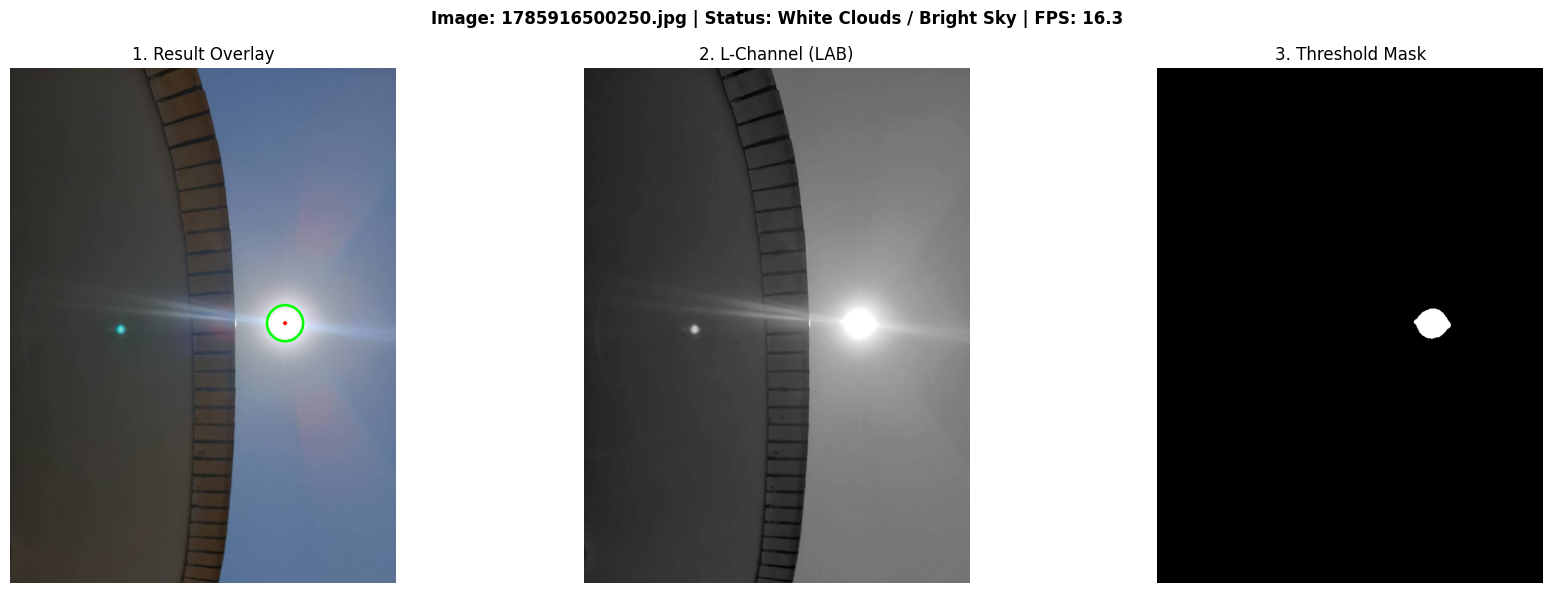

[2/35] 18219640_586.jpg | Mode: White Clouds Mode [Mean V: 167.6] | Time: 35.89 ms | FPS: 27.86


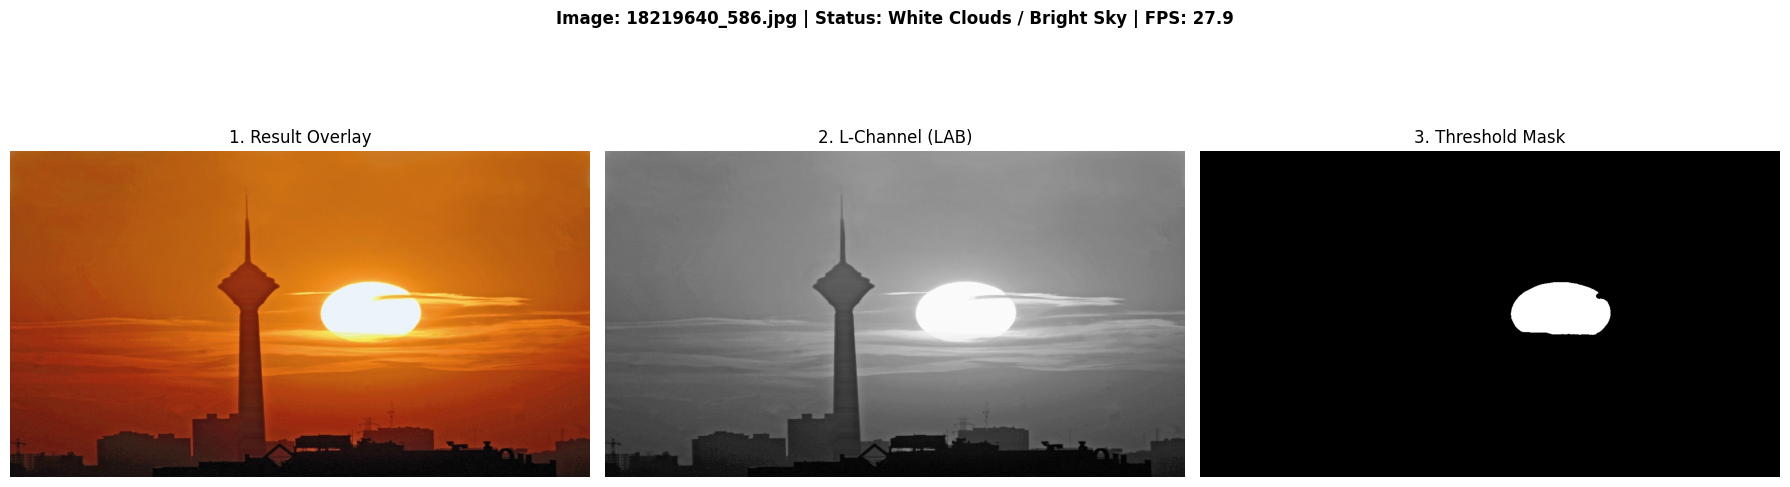

[3/35] IMG_20260805_180003.jpg | Mode: White Clouds Mode [Mean V: 110.7] | Time: 51.26 ms | FPS: 19.51


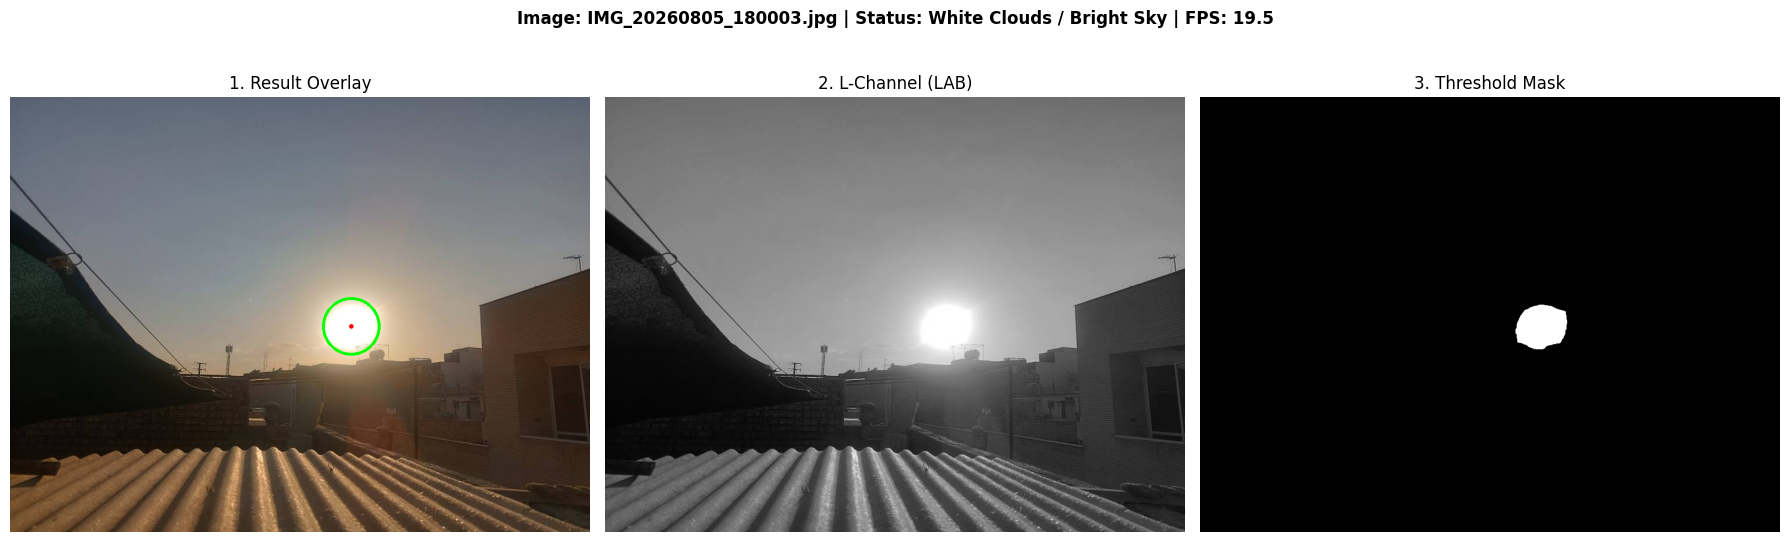

[4/35] IMG_20260805_180018.jpg | Mode: White Clouds Mode [Mean V: 101.6] | Time: 101.36 ms | FPS: 9.87


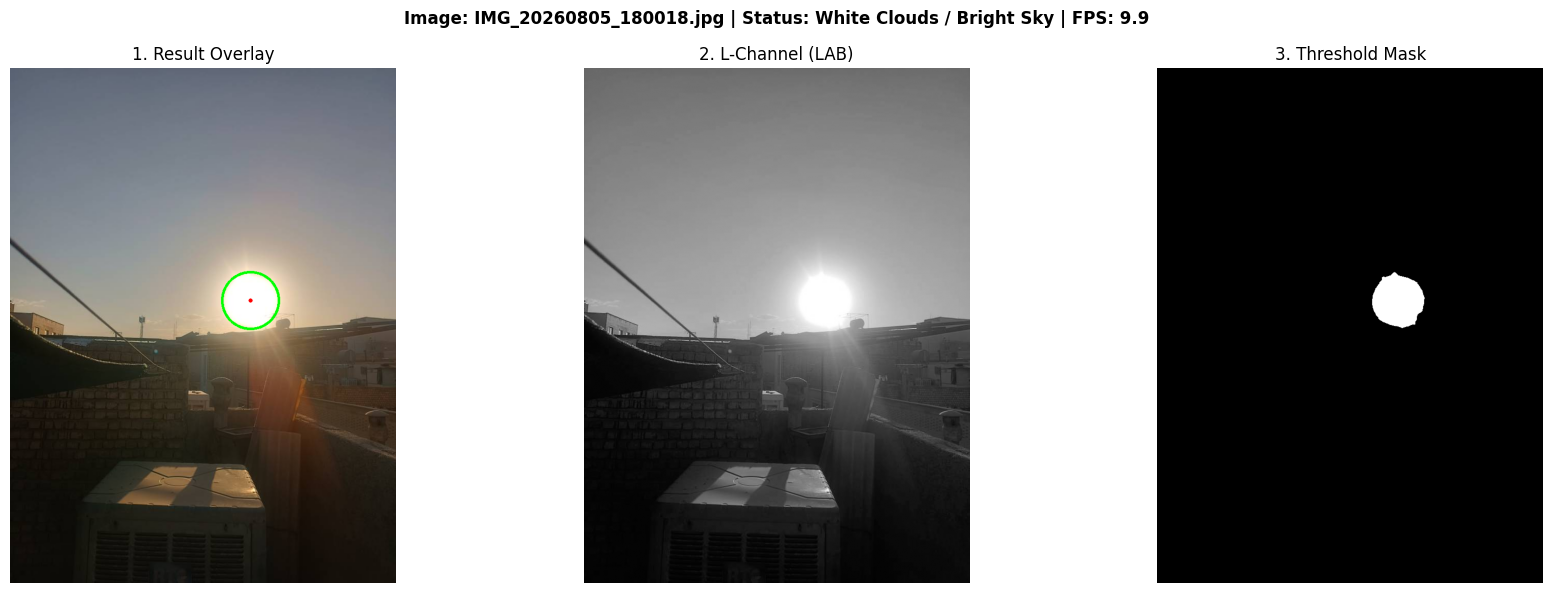

[5/35] IMG_20260805_180034.jpg | Mode: White Clouds Mode [Mean V: 102.2] | Time: 91.76 ms | FPS: 10.90


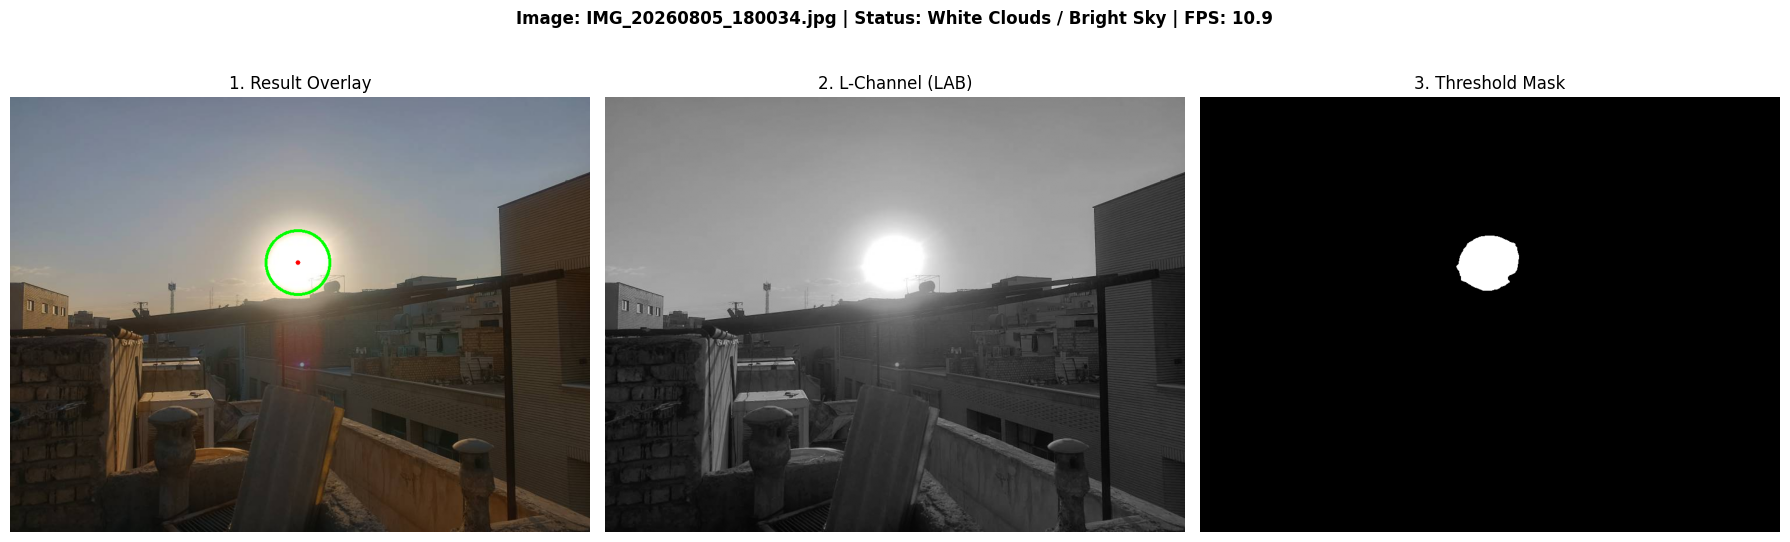

[6/35] IMG_20260805_180054.jpg | Mode: White Clouds Mode [Mean V: 112.6] | Time: 62.63 ms | FPS: 15.97


In [ ]:
import os
import glob
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Detection Parameters
# ==========================================================

RADIUS = 50
NIGHT_BRIGHTNESS_THRESH = 50  # آستانه روشنایی ۱۰٪ بالای تصویر برای شب (کمتر از این = شب)
DARK_L_THRESHOLD = 100
WHITE_L_THRESHOLD = 200
PIXEL_COUNT_THRESHOLD = 200

MIN_SUN_AREA_RATIO = 0.0002
MAX_SUN_AREA_RATIO = 0.6
MIN_CIRCULARITY = 0.5
MIN_SOLIDITY = 0.2
MIN_ASPECT_RATIO = 0.60
MAX_ASPECT_RATIO = 1.4
LOCAL_CONTRAST_LIMIT = 2
SUN_BRIGHTNESS_RATIO = 0.98
MIN_HOUGH_SCORE = 150.0


# ==========================================================
# 1. Sky & Cloud Classifier
# ==========================================================
def analyze_sky_and_clouds(frame):
    img = frame
    if img is None: 
        return False, {"error": "Error loading image"}

    # محاسبه میانگین brightness (از روی تصویر خاکستری یا کانال L)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mean_brightness = float(np.mean(gray))

    # محاسبه میانگین کانال V از HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_v = float(np.mean(hsv[:, :, 2]))

    # بررسی شب بودن (بر اساس ۲۰ درصد بالای تصویر)
    h, w = img.shape[:2]
    if np.mean(hsv[:int(0.1 * h), :, 2]) < NIGHT_BRIGHTNESS_THRESH:
        cv2.putText(img, "Status: Night", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 100, 0), 2, cv2.LINE_AA)
        
        # خروجی شب مطابق با دیکشنری مورد نظر
        return False, {
            "cloud_status": "Night / N/A",
            "brightness": mean_brightness,
            "v": mean_v
        }

    # تحلیل ابر و خورشید در روز
    l_channel = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)[:, :, 0]
    _, _, _, sun_center = cv2.minMaxLoc(cv2.GaussianBlur(l_channel, (11, 11), 0))

    mask = cv2.circle(np.zeros_like(l_channel), sun_center, RADIUS, 255, -1) > 0
    dark_count = np.sum((l_channel <= DARK_L_THRESHOLD) & mask)
    white_count = np.sum((l_channel >= WHITE_L_THRESHOLD) & mask)

    if dark_count >= PIXEL_COUNT_THRESHOLD:
        cloud_status, status_color = "Dark Clouds", (0, 0, 255)
    elif white_count >= PIXEL_COUNT_THRESHOLD:
        cloud_status, status_color = "White Clouds / Bright Sky", (255, 255, 0)
    else:
        cloud_status, status_color = "Clear / Moderate Sky", (0, 255, 0)

    # ترسیم روی تصویر
    # cv2.circle(img, sun_center, RADIUS, (255, 0, 0), 2)
    # cv2.circle(img, sun_center, 5, (0, 0, 255), -1)
    # cv2.putText(img, "Status: Day", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)
    # cv2.putText(img, f"Clouds: {cloud_status} (Dark: {dark_count}, White: {white_count})", 
    #             (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.6, status_color, 2, cv2.LINE_AA)

    # خروجی نهایی روز دقیقاً با کلیدهای: cloud_status, brightness, v
    return True, {
        "cloud_status": cloud_status,
        "brightness": mean_brightness,
        "v": mean_v
    }

# ==========================================================
# 2. Sun Detection Algorithm for White Clouds
# ==========================================================
def detect_sun_white(frame, offset_x=0, offset_y=0):
    if frame is None or frame.size == 0:
        return None, None, None, None, None

    h, w = frame.shape[:2]
    total_pixels = h * w

    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l_channel = lab[:, :, 0]
    blur_l = cv2.GaussianBlur(l_channel, (9, 9), 0)

    max_val = np.max(blur_l)
    custom_thresh_val = int(max_val * SUN_BRIGHTNESS_RATIO)
    _, mask_l = cv2.threshold(l_channel, custom_thresh_val, 255, cv2.THRESH_BINARY)

    kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))

    mask = cv2.morphologyEx(mask_l, cv2.MORPH_OPEN, kernel1)
    mask = cv2.morphologyEx(mask ,cv2.MORPH_CLOSE, kernel2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    best = None
    best_score = -1
    best_contour = None
    has_deformed_candidate = False

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < total_pixels * MIN_SUN_AREA_RATIO or area > total_pixels * MAX_SUN_AREA_RATIO:
            continue

        perimeter = cv2.arcLength(cnt, True)
        if perimeter <= 0:
            continue

        circularity = (4.0 * np.pi * area) / (perimeter * perimeter)

        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        if hull_area <= 0:
            continue

        solidity = area / hull_area
        if solidity < MIN_SOLIDITY:
            continue

        x, y, bw, bh = cv2.boundingRect(cnt)
        if bh == 0:
            continue

        aspect_ratio = bw / float(bh)
        if aspect_ratio < MIN_ASPECT_RATIO or aspect_ratio > MAX_ASPECT_RATIO:
            continue

        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue

        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        object_mask = np.zeros_like(mask)
        cv2.drawContours(object_mask, [cnt], -1, 255, -1)

        mean_l_value = cv2.mean(l_channel, mask=object_mask)[0]

        ring_mask = cv2.dilate(object_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31)))
        ring_mask = cv2.subtract(ring_mask, object_mask)
        background_l_value = cv2.mean(l_channel, mask=ring_mask)[0]
        local_contrast = mean_l_value - background_l_value

        if local_contrast < LOCAL_CONTRAST_LIMIT:
            continue

        if circularity < MIN_CIRCULARITY:
            has_deformed_candidate = True
            continue

        mean_bgr = cv2.mean(frame, mask=object_mask)[:3]
        (_, radius) = cv2.minEnclosingCircle(cnt)
        radius = int(radius)

        score = (mean_l_value * 1.8 + local_contrast * 8.0 + circularity * 250 + solidity * 250 + np.sqrt(area))

        if score > best_score:
            best_score = score
            best_contour = cnt
            best = {
                "center": (cx + offset_x, cy + offset_y),
                "radius_est": radius,
                "pixel_count": int(area),
                "mean_bgr": mean_bgr,
                "mean_value": mean_l_value,
                "local_contrast": local_contrast,
                "circularity": circularity,
                "solidity": solidity,
                "score": score,
                "method": "contour"
            }

    if best is None and has_deformed_candidate:
        print("hough")
        hough_input = cv2.GaussianBlur(mask, (5, 5), 0)
        min_r = int(np.sqrt(total_pixels * MIN_SUN_AREA_RATIO / np.pi))
        max_r = int(np.sqrt(total_pixels * MAX_SUN_AREA_RATIO / np.pi))

        circles = cv2.HoughCircles(
            hough_input, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30,
            param1=80, param2=10, minRadius=max(5, min_r), maxRadius=max_r
        )

        if circles is not None:
            circles = np.uint16(np.around(circles))
            best_hough = None
            best_hough_score = -1.0

            for c in circles[0, :]:
                cx_h, cy_h, r_h = int(c[0]), int(c[1]), int(c[2])
                if 0 <= cx_h < w and 0 <= cy_h < h and r_h > 0:
                    temp_circle_mask = np.zeros_like(mask)
                    cv2.circle(temp_circle_mask, (cx_h, cy_h), r_h, 255, -1)

                    overlap = cv2.bitwise_and(mask, temp_circle_mask)
                    bright_pixels = cv2.countNonZero(overlap)
                    if bright_pixels == 0:
                        continue

                    circle_area = np.pi * (r_h ** 2)
                    density = bright_pixels / circle_area
                    mean_l_inside = cv2.mean(l_channel, mask=temp_circle_mask)[0]

                    hough_score = (bright_pixels * density * 0.5) + (mean_l_inside * 1.2)

                    if hough_score > MIN_HOUGH_SCORE and hough_score > best_hough_score:
                        best_hough_score = hough_score
                        best_hough = (cx_h, cy_h, r_h, bright_pixels, mean_l_inside)

            if best_hough is not None:
                cx_h, cy_h, r_h, bright_pixels, mean_l_inside = best_hough
                final_hough_mask = np.zeros_like(mask)
                cv2.circle(final_hough_mask, (cx_h, cy_h), r_h, 255, -1)
                mean_bgr = cv2.mean(frame, mask=final_hough_mask)[:3]

                best = {
                    "center": (cx_h + offset_x, cy_h + offset_y),
                    "radius_est": r_h,
                    "pixel_count": bright_pixels,
                    "mean_bgr": mean_bgr,
                    "mean_value": mean_l_inside,
                    "local_contrast": 0.0,
                    "circularity": 1.0,
                    "solidity": 1.0,
                    "score": round(best_hough_score, 2),
                    "method": "hough"
                }

    return best, l_channel, mask, best_contour, mask


# ==========================================================
# 3. Sun Detection Algorithm for Dark Clouds
# ==========================================================
def detect_sun_dark(frame, offset_x=0, offset_y=0):
    if frame is None or frame.size == 0:
        return None, None, None, None, None

    h, w = frame.shape[:2]
    total_pixels = h * w

    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l_channel = lab[:, :, 0]
    blur_l = cv2.GaussianBlur(l_channel, (9, 9), 0)

    max_val = np.max(blur_l)
    custom_thresh_val = int(max_val * SUN_BRIGHTNESS_RATIO)
    _, mask_l = cv2.threshold(l_channel, custom_thresh_val, 255, cv2.THRESH_BINARY)

    kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))

    mask = cv2.morphologyEx(mask_l, cv2.MORPH_OPEN, kernel1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel2)

    hough_input = cv2.GaussianBlur(mask, (5, 5), 0)
    min_r = int(np.sqrt(total_pixels * MIN_SUN_AREA_RATIO / np.pi))
    max_r = int(np.sqrt(total_pixels * MAX_SUN_AREA_RATIO / np.pi))

    circles = cv2.HoughCircles(
        hough_input, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30,
        param1=80, param2=10, minRadius=max(5, min_r), maxRadius=max_r
    )

    best = None
    best_score = -1.0

    if circles is not None:
        circles = np.uint16(np.around(circles))

        for c in circles[0, :]:
            cx_h, cy_h, r_h = int(c[0]), int(c[1]), int(c[2])

            if 0 <= cx_h < w and 0 <= cy_h < h and r_h > 0:
                temp_circle_mask = np.zeros_like(mask)
                cv2.circle(temp_circle_mask, (cx_h, cy_h), r_h, 255, -1)

                overlap = cv2.bitwise_and(mask, temp_circle_mask)
                bright_pixels = cv2.countNonZero(overlap)
                if bright_pixels == 0:
                    continue

                circle_area = np.pi * (r_h ** 2)
                density = bright_pixels / circle_area

                mean_l_inside = cv2.mean(l_channel, mask=temp_circle_mask)[0]

                ring_mask = cv2.dilate(temp_circle_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21)))
                ring_mask = cv2.subtract(ring_mask, temp_circle_mask)
                bg_l_value = cv2.mean(l_channel, mask=ring_mask)[0]
                local_contrast = mean_l_inside - bg_l_value

                score = (bright_pixels * 0.4) + (density * 300.0) + (local_contrast * 5.0)

                if score > best_score:
                    best_score = score
                    final_mask = np.zeros_like(mask)
                    cv2.circle(final_mask, (cx_h, cy_h), r_h, 255, -1)
                    mean_bgr = cv2.mean(frame, mask=final_mask)[:3]

                    best = {
                        "center": (cx_h + offset_x, cy_h + offset_y),
                        "radius_est": r_h,
                        "pixel_count": bright_pixels,
                        "mean_bgr": mean_bgr,
                        "mean_value": mean_l_inside,
                        "local_contrast": local_contrast,
                        "circularity": 1.0,
                        "solidity": 1.0,
                        "score": round(score, 2),
                        "method": "hough_dark"
                    }

    return best, l_channel, mask, None, mask


# ==========================================================
# 4. Jupyter Lab Pipeline
# ==========================================================
def process_folder_jupyter(folder_path):
    extensions = ("*.jpg", "*.jpeg", "*.png", "*.bmp")
    image_paths = []
    for ext in extensions:
        image_paths.extend(glob.glob(os.path.join(folder_path, ext)))

    if not image_paths:
        print(f"هیچ تصویری در مسیر {folder_path} یافت نشد.")
        return

    print(f"تعداد {len(image_paths)} تصویر یافت شد.\n")

    total_proc_time = 0.0
    processed_count = 0

    for idx, img_path in enumerate(sorted(image_paths), start=1):
        frame = cv2.imread(img_path)
        if frame is None:
            continue

        filename = os.path.basename(img_path)

        t_start = time.perf_counter()

        is_day, details = analyze_sky_and_clouds(frame)
        cloud_status = details.get("cloud_status", "Unknown")
        top_brightness = details.get("brightness", 0.0)
        mean_v = details.get("v", 0.0)

        sun_result = None
        l_channel = None
        thresh_mask = None

        if not is_day:
            detection_mode = f"Night (Skipped) [Top 10% Brightness: {top_brightness:.1f}]"
        elif cloud_status == "Dark Clouds":
            detection_mode = f"Dark Clouds Mode [Mean V: {mean_v:.1f}]"
            sun_result, l_channel, thresh_mask, _, _ = detect_sun_dark(frame)
        else:
            detection_mode = f"White Clouds Mode [Mean V: {mean_v:.1f}]"
            sun_result, l_channel, thresh_mask, _, _ = detect_sun_white(frame)

        t_end = time.perf_counter()
        elapsed_time = t_end - t_start
        total_proc_time += elapsed_time
        processed_count += 1
        fps_frame = 1.0 / elapsed_time if elapsed_time > 0 else 0.0

        print(f"[{idx}/{len(image_paths)}] {filename} | Mode: {detection_mode} | Time: {elapsed_time*1000:.2f} ms | FPS: {fps_frame:.2f}")

        # --------------------------------------------------
        # نمایش درون‌برنامه‌ای مراحل در ژوپیتر لب
        # --------------------------------------------------
        vis_frame = frame.copy()
        
        if sun_result is not None:
            cx, cy = sun_result["center"]
            r = sun_result["radius_est"]
            cv2.circle(vis_frame, (cx, cy), r, (0, 255, 0), 3)
            cv2.circle(vis_frame, (cx, cy), 4, (0, 0, 255), -1)

        rgb_frame = cv2.cvtColor(vis_frame, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f"Image: {filename} | Status: {cloud_status} | FPS: {fps_frame:.1f}", fontsize=12, fontweight='bold')

        axes[0].imshow(rgb_frame)
        axes[0].set_title("1. Result Overlay")
        axes[0].axis("off")

        if l_channel is not None:
            axes[1].imshow(l_channel, cmap="gray")
            axes[1].set_title("2. L-Channel (LAB)")
        else:
            axes[1].set_title("2. L-Channel (N/A)")
        axes[1].axis("off")

        if thresh_mask is not None:
            axes[2].imshow(thresh_mask, cmap="gray")
            axes[2].set_title("3. Threshold Mask")
        else:
            axes[2].set_title("3. Threshold Mask (N/A)")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

    if processed_count > 0:
        avg_time = total_proc_time / processed_count
        avg_fps = processed_count / total_proc_time
        print("\n" + "="*50)
        print("گزارش نهایی بنچمارک سرعت (FPS Benchmark):")
        print(f"کل تصاویر پردازش شده: {processed_count}")
        print(f"میانگین زمان پردازش هر فریم: {avg_time*1000:.2f} ms")
        print(f"میانگین نرخ فریم (Average FPS): {avg_fps:.2f} FPS")
        print("="*50)


# ==========================================================
# اجرا در ژوپیتر لب
# ==========================================================
folder_path = "./images"  # آدرس پوشه تصاویر
process_folder_jupyter(folder_path)